Dataset Loaded Successfully!
Total Restaurants: 9551

Online Delivery Distribution:
Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64

Percentage Distribution:
Has Online delivery
No     74.34
Yes    25.66
Name: count, dtype: float64

Results:
  Online Delivery  Restaurant Count  Percentage (%)
0              No              7100           74.34
1             Yes              2451           25.66

Average Ratings:
Has Online delivery
No     2.47
Yes    3.25
Name: Aggregate rating, dtype: float64


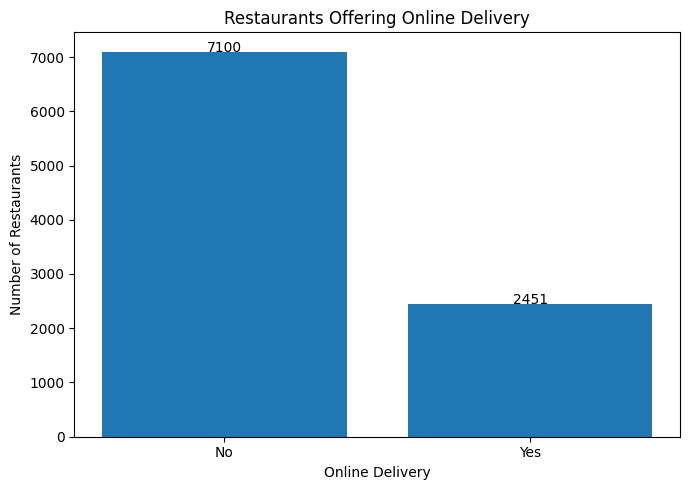

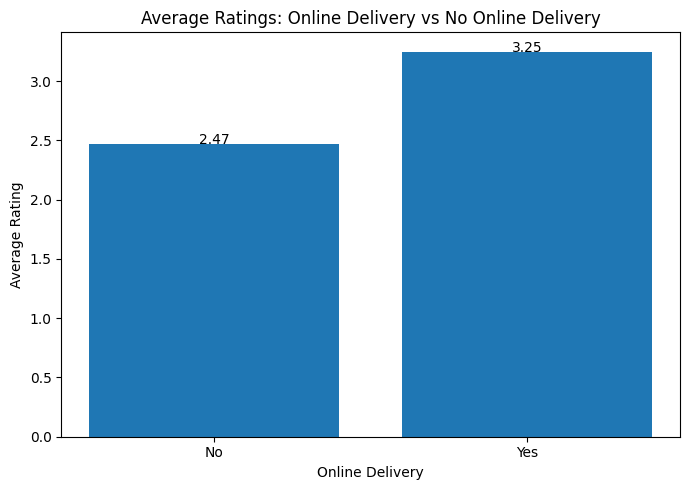

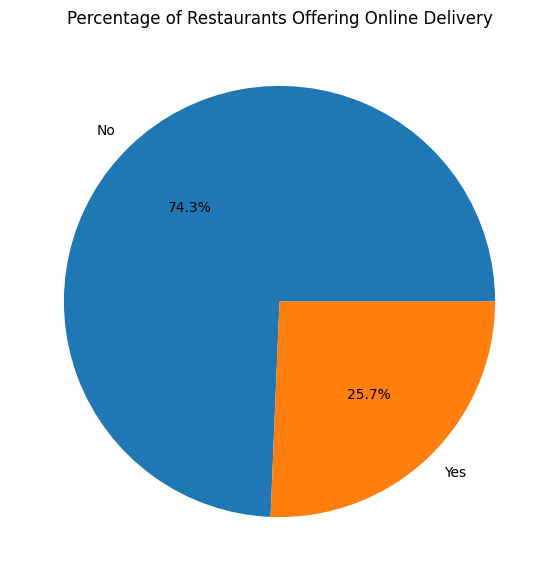


Conclusion:
25.66% of restaurants offer online delivery.
74.34% of restaurants do not offer online delivery.
Restaurants with online delivery have higher average ratings (3.25) than those without (2.47).

Delivery Distribution Table


,Online Delivery,Restaurant Count,Percentage (%)
0,No,7100,74.34
1,Yes,2451,25.66



Average Rating Comparison


Has Online delivery
No     2.47
Yes    3.25
Name: Aggregate rating, dtype: float64

In [1]:
# ==========================================================
# Cognifyz Data Analysis Internship
# Level 1 - Task 4: Online Delivery Analysis
# ==========================================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Load Dataset
# ----------------------------------------------------------

df = pd.read_csv(r"D:\2 Year iv sem\Python\Cognifyz-Data-Analysis\Dataset .csv")

print("Dataset Loaded Successfully!")
print(f"Total Restaurants: {len(df)}")

# ----------------------------------------------------------
# Restaurants Offering Online Delivery
# ----------------------------------------------------------

online_delivery_counts = df["Has Online delivery"].value_counts()

print("\nOnline Delivery Distribution:")
print(online_delivery_counts)

# ----------------------------------------------------------
# Calculate Percentage
# ----------------------------------------------------------

online_delivery_percentage = round(
    (online_delivery_counts / len(df)) * 100,
    2
)

print("\nPercentage Distribution:")
print(online_delivery_percentage)

# ----------------------------------------------------------
# Create Result Table
# ----------------------------------------------------------

delivery_result = pd.DataFrame({
    "Online Delivery": online_delivery_percentage.index,
    "Restaurant Count": online_delivery_counts.values,
    "Percentage (%)": online_delivery_percentage.values
})

print("\nResults:")
print(delivery_result)

# ----------------------------------------------------------
# Average Ratings Comparison
# ----------------------------------------------------------

average_ratings = df.groupby(
    "Has Online delivery"
)["Aggregate rating"].mean().round(2)

print("\nAverage Ratings:")
print(average_ratings)

# ----------------------------------------------------------
# Bar Chart - Online Delivery Distribution
# ----------------------------------------------------------

plt.figure(figsize=(7,5))

bars = plt.bar(
    delivery_result["Online Delivery"],
    delivery_result["Restaurant Count"]
)

plt.title("Restaurants Offering Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Number of Restaurants")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center'
    )

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Bar Chart - Average Rating Comparison
# ----------------------------------------------------------

plt.figure(figsize=(7,5))

bars = plt.bar(
    average_ratings.index,
    average_ratings.values
)

plt.title("Average Ratings: Online Delivery vs No Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        round(height, 2),
        ha='center'
    )

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Pie Chart
# ----------------------------------------------------------

plt.figure(figsize=(7,7))

plt.pie(
    delivery_result["Restaurant Count"],
    labels=delivery_result["Online Delivery"],
    autopct="%1.1f%%"
)

plt.title("Percentage of Restaurants Offering Online Delivery")
plt.show()

# ----------------------------------------------------------
# Conclusion
# ----------------------------------------------------------

online_percentage = online_delivery_percentage.get("Yes", 0)
offline_percentage = online_delivery_percentage.get("No", 0)

print("\nConclusion:")
print(f"{online_percentage}% of restaurants offer online delivery.")
print(f"{offline_percentage}% of restaurants do not offer online delivery.")

if average_ratings["Yes"] > average_ratings["No"]:
    print(
        f"Restaurants with online delivery have higher average ratings "
        f"({average_ratings['Yes']}) than those without "
        f"({average_ratings['No']})."
    )
else:
    print(
        f"Restaurants without online delivery have higher average ratings "
        f"({average_ratings['No']}) than those with "
        f"({average_ratings['Yes']})."
    )

# ----------------------------------------------------------
# Display Final Tables
# ----------------------------------------------------------

print("\nDelivery Distribution Table")
display(delivery_result)

print("\nAverage Rating Comparison")
display(average_ratings)